In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# given datapoints
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

In [3]:
# Part A - Cubic Spline Interpolation

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1]) # Right-hand side vector
    return A, B, C, D

def thomas_algorithm(a, b, c, d): # calculate second derivatives
    n = len(b)
   
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x, x_val, M): # custom code for creating the spline (in place of built-in CubicSpline function)
    n = len(x)
    m = len(x_val)
    h = np.diff(x)
    S = np.zeros(m)

    for i in range(0, m):
        j = 0
        while x_val[i] > x[j+1]:
            j += 1
                    
        S[i] = M[j]/(6*h[j])*((x[j+1] - x_val[i])**3) + M[j+1]/(6*h[j])*((x_val[i] - x[j])**3) + (y[j]/h[j] - M[j]*h[j]/6)*(x[j+1] - x_val[i]) + (y[j+1]/h[j] - M[j+1]*h[j]/6)*(x_val[i] - x[j])
    
    return S

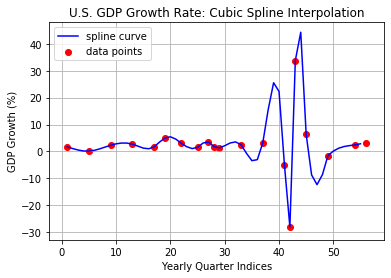

In [4]:
x_full = np.arange(1, 56)

A, B, C, D = setup_tridiagonal_matrix(x, y)
M_part = thomas_algorithm(A, B, C, D)
M = np.concatenate(([0], M_part, [0]))
spline = evaluate_spline(x, x_full, M)

# plot cubic spline
plt.plot(x_full, spline, 'b', label='spline curve')
plt.scatter(x, y, color='r', label='data points')
plt.legend()
plt.xlabel("Yearly Quarter Indices")
plt.ylabel("GDP Growth (%)")
plt.title("U.S. GDP Growth Rate: Cubic Spline Interpolation")
plt.grid()
plt.show()

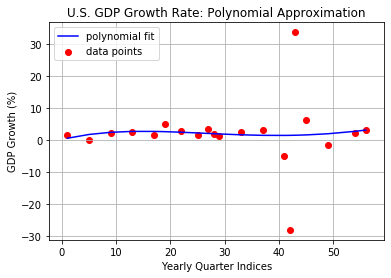

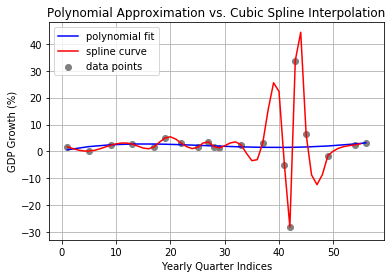

In [5]:
# Part B - Polynomial & Least Squares Comparison

degree = 4

def create_vandermonde_matrix(x, y, degree): # custom code for generating Vandermonde Matrix (in place of 'np.vander' function)
    V_list = []
    n = len(x)
    m = degree + 1
    
    for i in range(n): # creating rows of each x value to a power of 0 through degree number
        row = []
        for j in range(m):
            row.append(x[i]**j)
            
        V_list.append(row) # stacking each row (creating columns)
    
    V = np.array(V_list) # turning the list into an array
    return V
        
V = create_vandermonde_matrix(x, y, degree)
# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, y)
# Solve for a (coefficients)
coefficient = np.linalg.solve(VT_V, VT_y)

    
polynomial = 0
n = len(coefficient)
for i in range (n):
    polynomial += coefficient[i]*(x**i)

# plot polynomial approximation
plt.plot(x, polynomial, color='b', label='polynomial fit')
plt.scatter(x, y, color='r', label='data points')
plt.legend()
plt.xlabel("Yearly Quarter Indices")
plt.ylabel("GDP Growth (%)")
plt.title("U.S. GDP Growth Rate: Polynomial Approximation")
plt.grid()
plt.show()

# plot polynomial alongside cubic spline
plt.plot(x, polynomial, color='b', label='polynomial fit')
plt.plot(x_full, spline, 'r', label='spline curve')
plt.scatter(x, y, color='grey', label='data points')
plt.legend()
plt.xlabel("Yearly Quarter Indices")
plt.ylabel("GDP Growth (%)")
plt.title("Polynomial Approximation vs. Cubic Spline Interpolation")
plt.grid()
plt.show()

In [6]:
# Mean Squared Error (MSE)
mse = np.mean((y - polynomial)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - polynomial)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 100.6298
R-squared: 0.0035


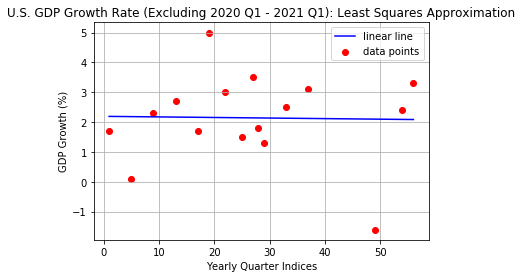

slope = -0.00190698818897635


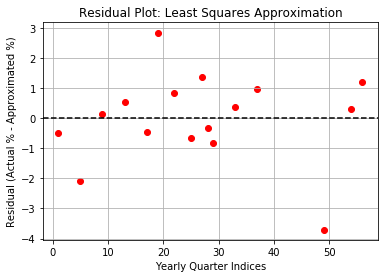

In [7]:
# Least Squares Method

def leastSquaresMethod(x, y, n): # function to find the slope and intercept of line
    xsum = 0
    ysum = 0
    xxsum = 0
    xysum = 0

    for i in range(n):
        xsum += x[i]
        ysum += y[i]
        xxsum += (x[i]**2)
        xysum += (x[i] * y[i])

    m = ((n * xysum) - (xsum * ysum)) / (n * xxsum - (xsum**2))
    c = (ysum - m * xsum) / n
    
    return m, c

# removing datapoints corresponding to COVID years (2020 Q1–2021 Q1)
x1 = x[0:13]
x2 = x[17:]
x_noCovid = np.concatenate([x1, x2])
n = len(x_noCovid)

y1 = y[0:13]
y2 = y[17:]
y_noCovid = np.concatenate([y1, y2])


m, c = leastSquaresMethod(x_noCovid, y_noCovid, n)
yeq = m*x_noCovid + c

# plot linear approximation
plt.scatter(x_noCovid, y_noCovid, label='data points', color='r')
plt.plot(x_noCovid, yeq, label='linear line', color='b')
plt.legend()
plt.xlabel("Yearly Quarter Indices")
plt.ylabel("GDP Growth (%)")
plt.title("U.S. GDP Growth Rate (Excluding 2020 Q1 - 2021 Q1): Least Squares Approximation")
plt.grid()
plt.show()

print("slope =", m)

# plot residuals
residual = y_noCovid - yeq
plt.scatter(x_noCovid, residual, color='r')
plt.xlabel("Yearly Quarter Indices")
plt.ylabel("Residual (Actual % - Approximated %)")
plt.title("Residual Plot: Least Squares Approximation")
plt.axhline(0, color='black', linestyle='--')
plt.grid()
plt.show()

In [8]:
# Mean Squared Error (MSE)
mse = np.mean((y_noCovid - yeq)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value
ss_total = np.sum((y_noCovid - np.mean(y_noCovid))**2)
ss_res = np.sum((y_noCovid - yeq)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 2.0828
R-squared: 0.0004


Citation: 

Part B - Polynomial Approximation:
I searched on my Chrome browser "how to turn a list into a matrix python" and found the website: https://www.geeksforgeeks.org/python/python-convert-list-to-python-array/, where I read that I could use "numpy.array()" function.


Part B - Least Squares Method:
I searched into Google Gemini "difference between scatter plot and residual plot" and learned to take the actual minus the approximated y-value and plot it against the x values. Furthermore, I read how to draw a line across the horizontal axis to clearly display the distance between the datapoints and the linear model.